### Import Required Libraries

In [21]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, mean_absolute_error,
    mean_squared_error, r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



In [22]:
pd.set_option("display.max_columns", None)

if Path("titanic.csv").exists():
    pass
elif Path("analytics/titanic.csv").exists():
    os.chdir("analytics")

df = pd.read_csv("titanic.csv")
print("Loaded:", df.shape)
display(df.head())

Loaded: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Create/use the analytics directory
Path("analytics").mkdir(exist_ok=True)
os.chdir("analytics")

print("Working directory:", Path.cwd())

# ONE AND ONLY RAW DATASET LOAD
df = sns.load_dataset("titanic")

# Required offline fallback
df.to_csv("titanic.csv", index=False)

print("Dataset loaded and offline fallback saved.")


Working directory: C:\Users\sreen\Masai_AIML_Telugu\analytics\analytics
Dataset loaded and offline fallback saved.


In [4]:
print("Shape:", df.shape)
print("\nINFO:")
df.info()

print("\nDESCRIBE:")
display(df.describe(include="all").T)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("\nMissing-value percentage for affected columns:")
display(missing_pct.to_frame("missing_percentage"))


Shape: (891, 15)

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

DESCRIBE:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing-value percentage for affected columns:


,missing_percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


## Missing-value strategy

Required rule:
- **< 5% missing:** drop rows containing missing values in that column.
- **5%–30% missing:** impute.
- **Very high missingness:** explicitly decide whether to drop the column or encode missing as a category.

The next cell calculates the percentages and applies a defensible strategy. For the Titanic data, `deck` has very high missingness, so it is dropped rather than imputed. `age` is imputed because its missingness is in the 5%–30% range. `embarked`/`embark_town` have low missingness, so rows with missing values are removed.


In [5]:
# Work from the same loaded DataFrame
clean_df = df.copy()

missing_before = clean_df.isna().mean() * 100

# Very high missingness: drop the column
if "deck" in clean_df.columns:
    print(f"deck: {missing_before['deck']:.2f}% missing -> DROP COLUMN (too much missingness for reliable imputation)")
    clean_df = clean_df.drop(columns=["deck"])

# 5%-30%: median imputation for numeric age
if "age" in clean_df.columns and clean_df["age"].isna().any():
    pct = missing_before["age"]
    print(f"age: {pct:.2f}% missing -> MEDIAN IMPUTATION")
    clean_df["age"] = clean_df["age"].fillna(clean_df["age"].median())

# <5%: drop rows for categorical low-missingness columns
for col in ["embarked", "embark_town"]:
    if col in clean_df.columns and clean_df[col].isna().any():
        pct = missing_before[col]
        print(f"{col}: {pct:.2f}% missing -> DROP ROWS")

clean_df = clean_df.dropna(subset=[c for c in ["embarked", "embark_town"] if c in clean_df.columns])

# Verify
print("\nRemaining missing values:")
display((clean_df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_percentage"))
print("Cleaned shape:", clean_df.shape)


deck: 77.22% missing -> DROP COLUMN (too much missingness for reliable imputation)
age: 19.87% missing -> MEDIAN IMPUTATION
embarked: 0.22% missing -> DROP ROWS
embark_town: 0.22% missing -> DROP ROWS

Remaining missing values:


,missing_percentage
survived,0.0
pclass,0.0
sex,0.0
age,0.0
sibsp,0.0
parch,0.0
fare,0.0
embarked,0.0
class,0.0
who,0.0


Cleaned shape: (889, 14)


### Save the file

In [6]:
# Save the cleaned version for convenient inspection.
# The required raw-load fallback remains titanic.csv and was created immediately after loading.
clean_df.to_csv("titanic_clean.csv", index=False)


# Univariate analysis — age and fare

We use the IQR rule:
`lower = Q1 - 1.5 * IQR`
`upper = Q3 + 1.5 * IQR`

Any value outside those bounds is counted as an outlier.


In [7]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return int(mask.sum()), q1, q3, iqr, lower, upper

for col in ["age", "fare"]:
    count, q1, q3, iqr, lower, upper = iqr_outliers(clean_df[col])
    print(f"{col}: outliers={count}, Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, bounds=[{lower:.2f}, {upper:.2f}]")


age: outliers=65, Q1=22.00, Q3=35.00, IQR=13.00, bounds=[2.50, 54.50]
fare: outliers=114, Q1=7.90, Q3=31.00, IQR=23.10, bounds=[-26.76, 65.66]


C:\Users\sreen\conda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


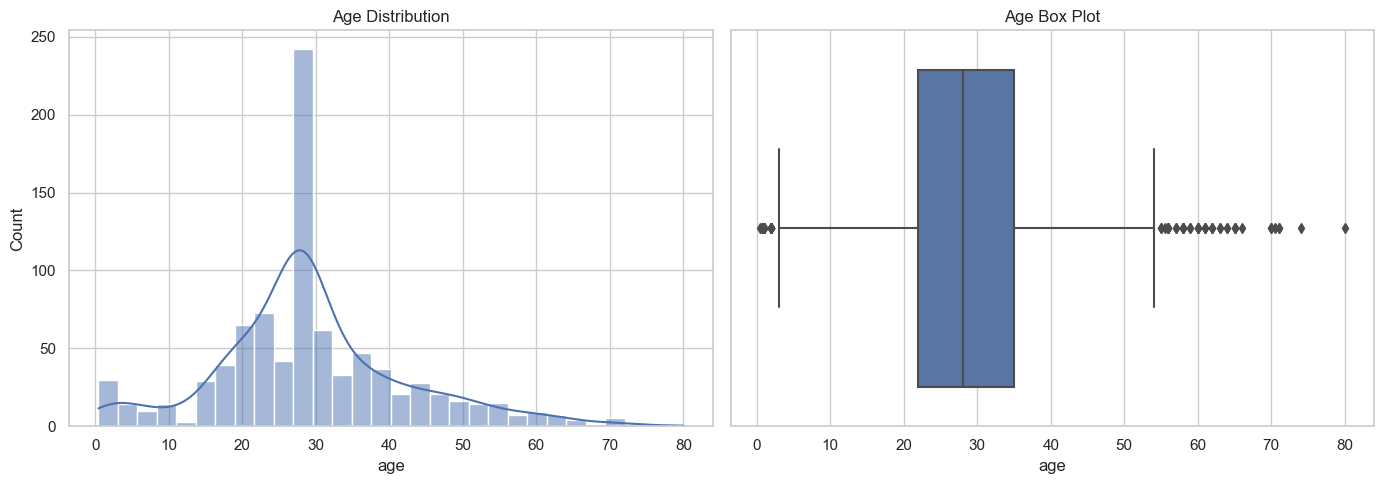

C:\Users\sreen\conda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


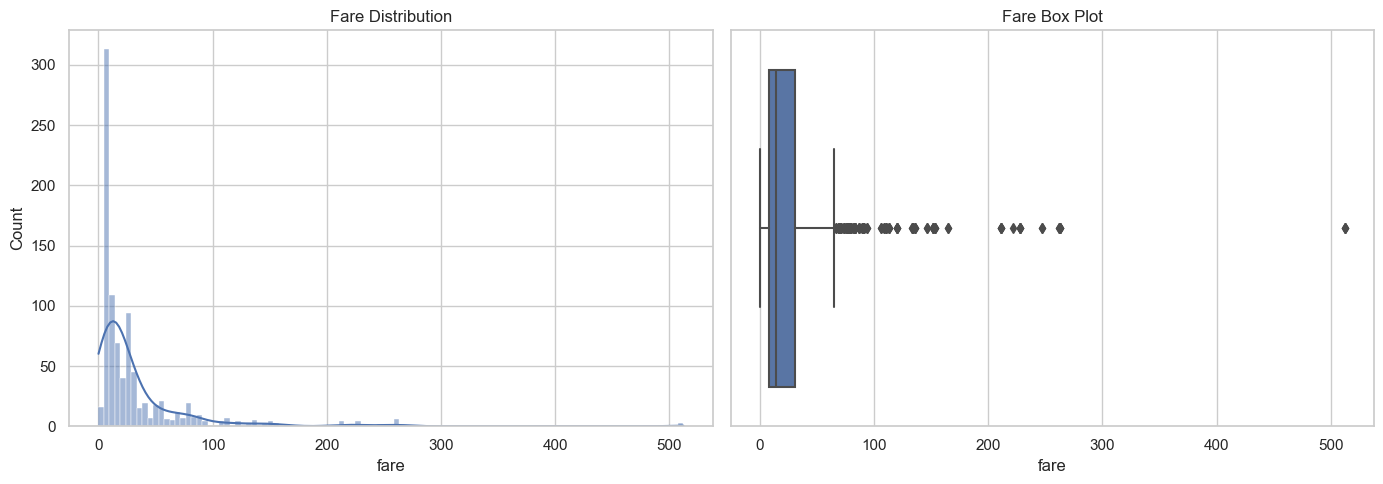

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(clean_df["age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.boxplot(x=clean_df["age"], ax=axes[1])
axes[1].set_title("Age Box Plot")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(clean_df["fare"], kde=True, ax=axes[0])
axes[0].set_title("Fare Distribution")

sns.boxplot(x=clean_df["fare"], ax=axes[1])
axes[1].set_title("Fare Box Plot")
plt.tight_layout()
plt.show()


In [9]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode().iloc[0]

print(f"Fare mean   : {fare_mean:.4f}")
print(f"Fare median : {fare_median:.4f}")
print(f"Fare mode   : {fare_mode:.4f}")

if fare_mean > fare_median:
    skew_text = "right-skewed"
elif fare_mean < fare_median:
    skew_text = "left-skewed"
else:
    skew_text = "approximately symmetric"

print(f"Conclusion: Fare is {skew_text}, because mean={fare_mean:.2f}, median={fare_median:.2f}, mode={fare_mode:.2f}.")


Fare mean   : 32.0967
Fare median : 14.4542
Fare mode   : 8.0500
Conclusion: Fare is right-skewed, because mean=32.10, median=14.45, mode=8.05.


#### Bivariate analysis — survival rates

Boolean masking with `&`/`|` is used below to demonstrate explicit subgroup calculations.


In [10]:
# Survival by sex
sex_survival = clean_df.groupby("sex")["survived"].mean().mul(100).round(2)
print("Survival rate by sex (%):")
display(sex_survival)

# Survival by pclass
pclass_survival = clean_df.groupby("pclass")["survived"].mean().mul(100).round(2)
print("Survival rate by pclass (%):")
display(pclass_survival)

# Explicit boolean masking examples
female_survival = clean_df.loc[clean_df["sex"] == "female", "survived"].mean() * 100
male_survival = clean_df.loc[clean_df["sex"] == "male", "survived"].mean() * 100

first_class_survival = clean_df.loc[clean_df["pclass"] == 1, "survived"].mean() * 100
third_class_survival = clean_df.loc[clean_df["pclass"] == 3, "survived"].mean() * 100

female_first = clean_df.loc[(clean_df["sex"] == "female") & (clean_df["pclass"] == 1), "survived"].mean() * 100
male_third = clean_df.loc[(clean_df["sex"] == "male") & (clean_df["pclass"] == 3), "survived"].mean() * 100

print(f"Female survival: {female_survival:.2f}%")
print(f"Male survival: {male_survival:.2f}%")
print(f"1st-class survival: {first_class_survival:.2f}%")
print(f"3rd-class survival: {third_class_survival:.2f}%")
print(f"Female + 1st class survival: {female_first:.2f}%")
print(f"Male + 3rd class survival: {male_third:.2f}%")


Survival rate by sex (%):


sex
female    74.04
male      18.89
Name: survived, dtype: float64

Survival rate by pclass (%):


pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64

Female survival: 74.04%
Male survival: 18.89%
1st-class survival: 62.62%
3rd-class survival: 24.24%
Female + 1st class survival: 96.74%
Male + 3rd class survival: 13.54%


Exactly the required 6x6 correlation matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


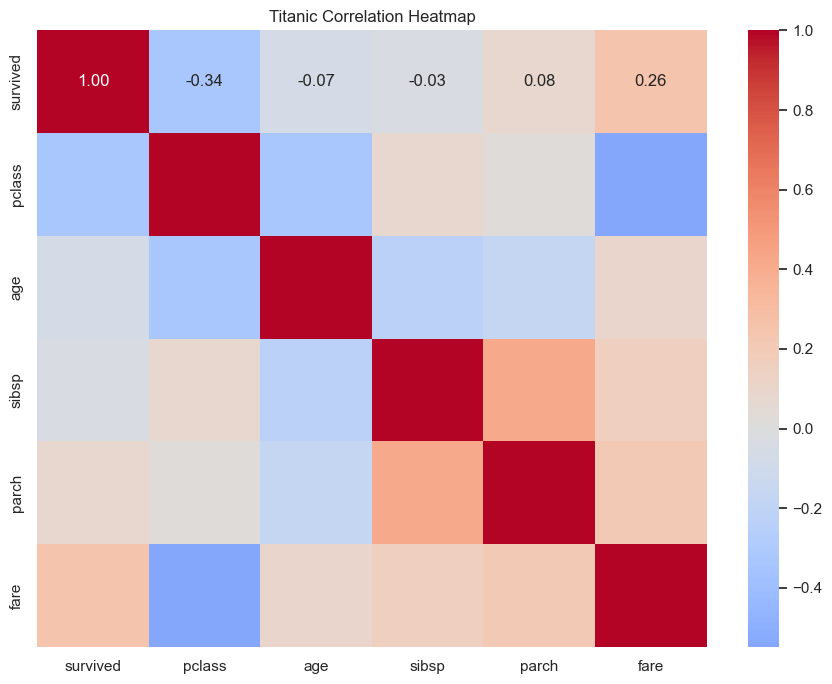

Two strongest correlations:
pclass vs fare: correlation=-0.5482, absolute=0.5482
sibsp vs parch: correlation=0.4145, absolute=0.4145


In [11]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = clean_df[corr_cols].corr()

print("Exactly the required 6x6 correlation matrix:")
display(corr)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.show()

# Find the two strongest absolute off-diagonal correlations
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        a, b = corr_cols[i], corr_cols[j]
        pairs.append((a, b, corr.loc[a, b], abs(corr.loc[a, b])))

top_two = sorted(pairs, key=lambda x: x[3], reverse=True)[:2]

print("Two strongest correlations:")
for a, b, value, absolute_value in top_two:
    print(f"{a} vs {b}: correlation={value:.4f}, absolute={absolute_value:.4f}")


# Multivariate data story

### Chart 1 — Survival by sex
Females and males have substantially different survival rates in the cleaned Titanic data. This indicates that sex is strongly associated with the survival outcome.


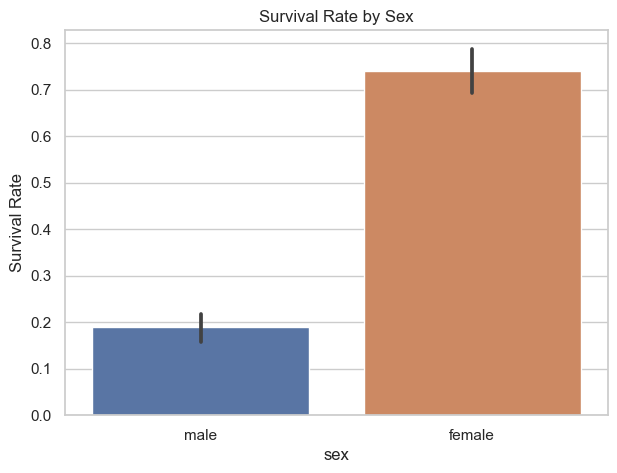

In [13]:
plt.figure(figsize=(7, 5))
sns.barplot(data=clean_df, x="sex", y="survived", estimator=np.mean)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()


### Chart 2 — Survival by passenger class
Survival rates vary across passenger classes. This suggests socioeconomic/passenger-class differences are relevant to survival.

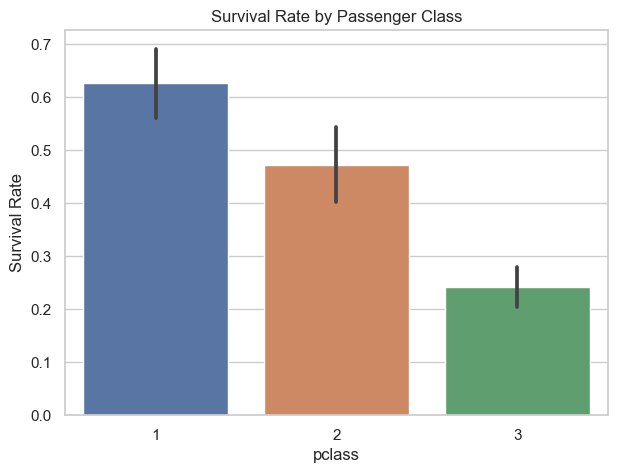

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(data=clean_df, x="pclass", y="survived", estimator=np.mean)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()






### Chart 3 — Sex × passenger class
Combining sex and class reveals interaction between the two variables. The subgroup rates show that survival cannot be fully described by either variable independently.

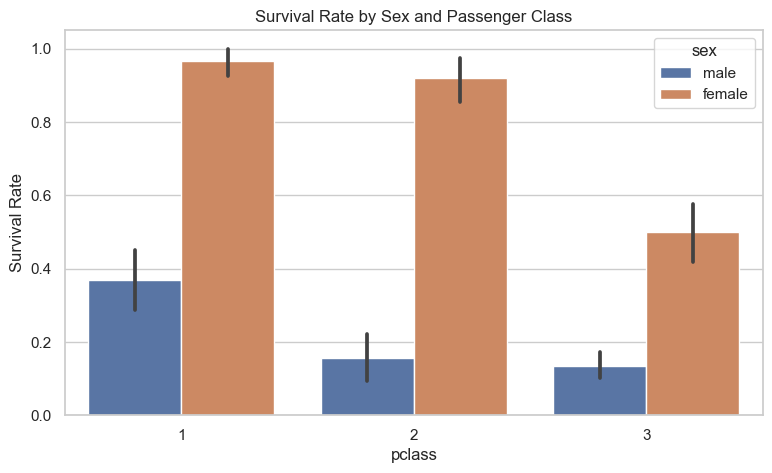

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(data=clean_df, x="pclass", y="survived", hue="sex", estimator=np.mean)
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


### Chart 4 — Age/Fare and survival
Age and fare distributions provide additional context around the passengers who survived and those who did not.


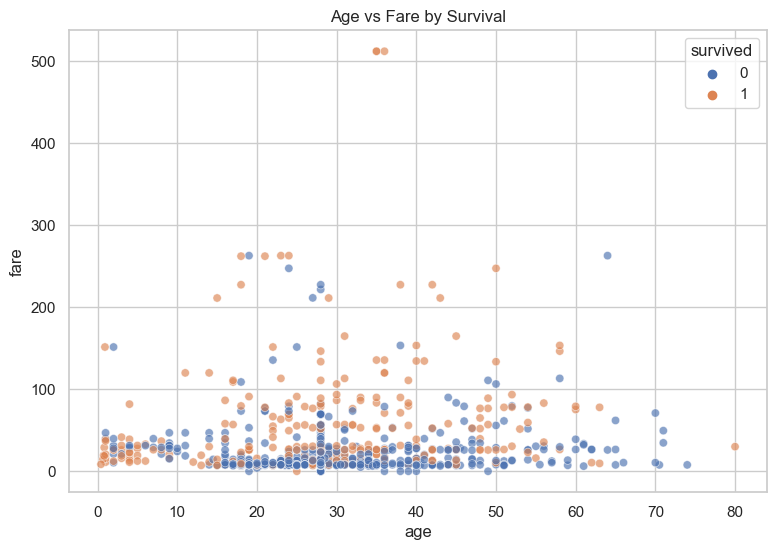

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=clean_df, x="age", y="fare", hue="survived", alpha=0.65)
plt.title("Age vs Fare by Survival")
plt.show()


In [18]:

scaler_eda = StandardScaler()
clean_df[["age_z", "fare_z"]] = scaler_eda.fit_transform(clean_df[["age", "fare"]])

comparison = pd.DataFrame({
    "age_before_mean": [clean_df["age"].mean()],
    "age_before_std": [clean_df["age"].std(ddof=0)],
    "age_after_mean": [clean_df["age_z"].mean()],
    "age_after_std": [clean_df["age_z"].std(ddof=0)],
    "fare_before_mean": [clean_df["fare"].mean()],
    "fare_before_std": [clean_df["fare"].std(ddof=0)],
    "fare_after_mean": [clean_df["fare_z"].mean()],
    "fare_after_std": [clean_df["fare_z"].std(ddof=0)]
})
display(comparison)

print("The standardized columns should have means approximately 0 and population standard deviations approximately 1.")


,age_before_mean,age_before_std,age_after_mean,age_after_std,fare_before_mean,fare_before_std,fare_after_mean,fare_after_std
0,29.315152,12.977627,2.717486e-16,1.0,32.096681,49.669545,1.398706e-16,1.0


The standardized columns should have means approximately 0 and population standard deviations approximately 1.


#### Part B — Predictive modeling, continuing from the same cleaned data

In [23]:
# Reproduce the EDA cleaning decisions without any raw network reload.
if "deck" in df.columns:
    df = df.drop(columns=["deck"])

if "age" in df.columns:
    df["age"] = df["age"].fillna(df["age"].median())

for col in ["embarked", "embark_town"]:
    if col in df.columns:
        df = df.dropna(subset=[col])

print("Modeling dataset:", df.shape)
print("Missing values:")
display(df.isna().sum()[df.isna().sum() > 0])


Modeling dataset: (889, 14)
Missing values:


Series([], dtype: int64)

## Stratified train/test split

`survived` is the classification target. Stratification preserves approximately the same survived/not-survived class proportions in both train and test sets, which is important when evaluating classification metrics.


In [24]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nOverall class balance:")
display(y.value_counts(normalize=True).rename("proportion"))

print("\nTrain class balance:")
display(y_train.value_counts(normalize=True).rename("proportion"))

print("\nTest class balance:")
display(y_test.value_counts(normalize=True).rename("proportion"))


Train: (711, 13) Test: (178, 13)

Overall class balance:


survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


Train class balance:


survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64


Test class balance:


survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64

In [25]:
# Select modeling features.
# Exclude derived/redundant boolean flags adult_male and alone.
drop_features = [c for c in ["adult_male", "alone"] if c in X_train.columns]

X_train_m = X_train.drop(columns=drop_features)
X_test_m = X_test.drop(columns=drop_features)

numeric_features = X_train_m.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_m.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class', 'who', 'embark_town', 'alive']


In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    )
}

results = {}
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])
    pipe.fit(X_train_m, y_train)
    fitted_pipelines[name] = pipe

    pred = pipe.predict(X_test_m)
    proba = pipe.predict_proba(X_test_m)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
        "Confusion Matrix": confusion_matrix(y_test, pred)
    }

results_df = pd.DataFrame(results).T
display(results_df[["Accuracy", "Precision", "Recall", "F1", "AUC"]])


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0


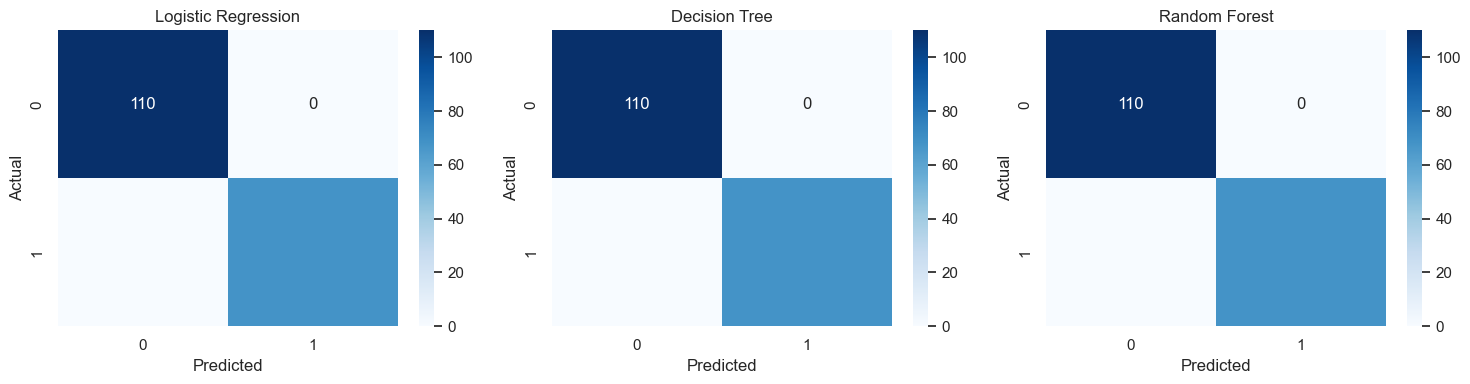

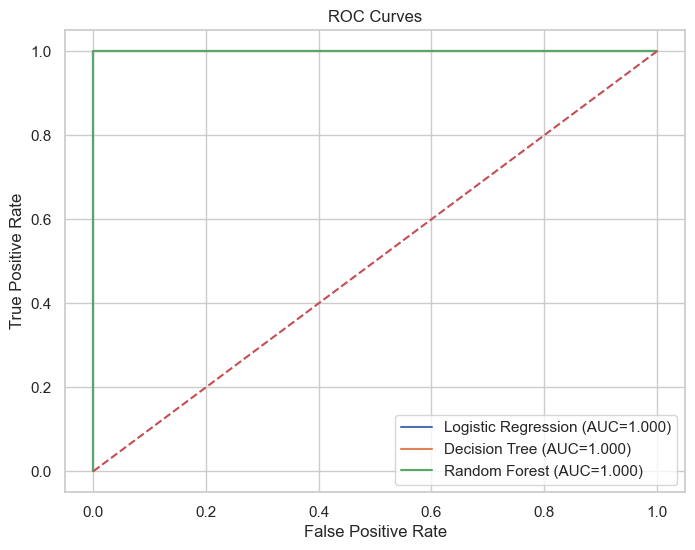

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0


In [27]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, metrics) in zip(axes, results.items()):
    sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test_m)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

display(results_df[["Accuracy", "Precision", "Recall", "F1", "AUC"]].round(4))


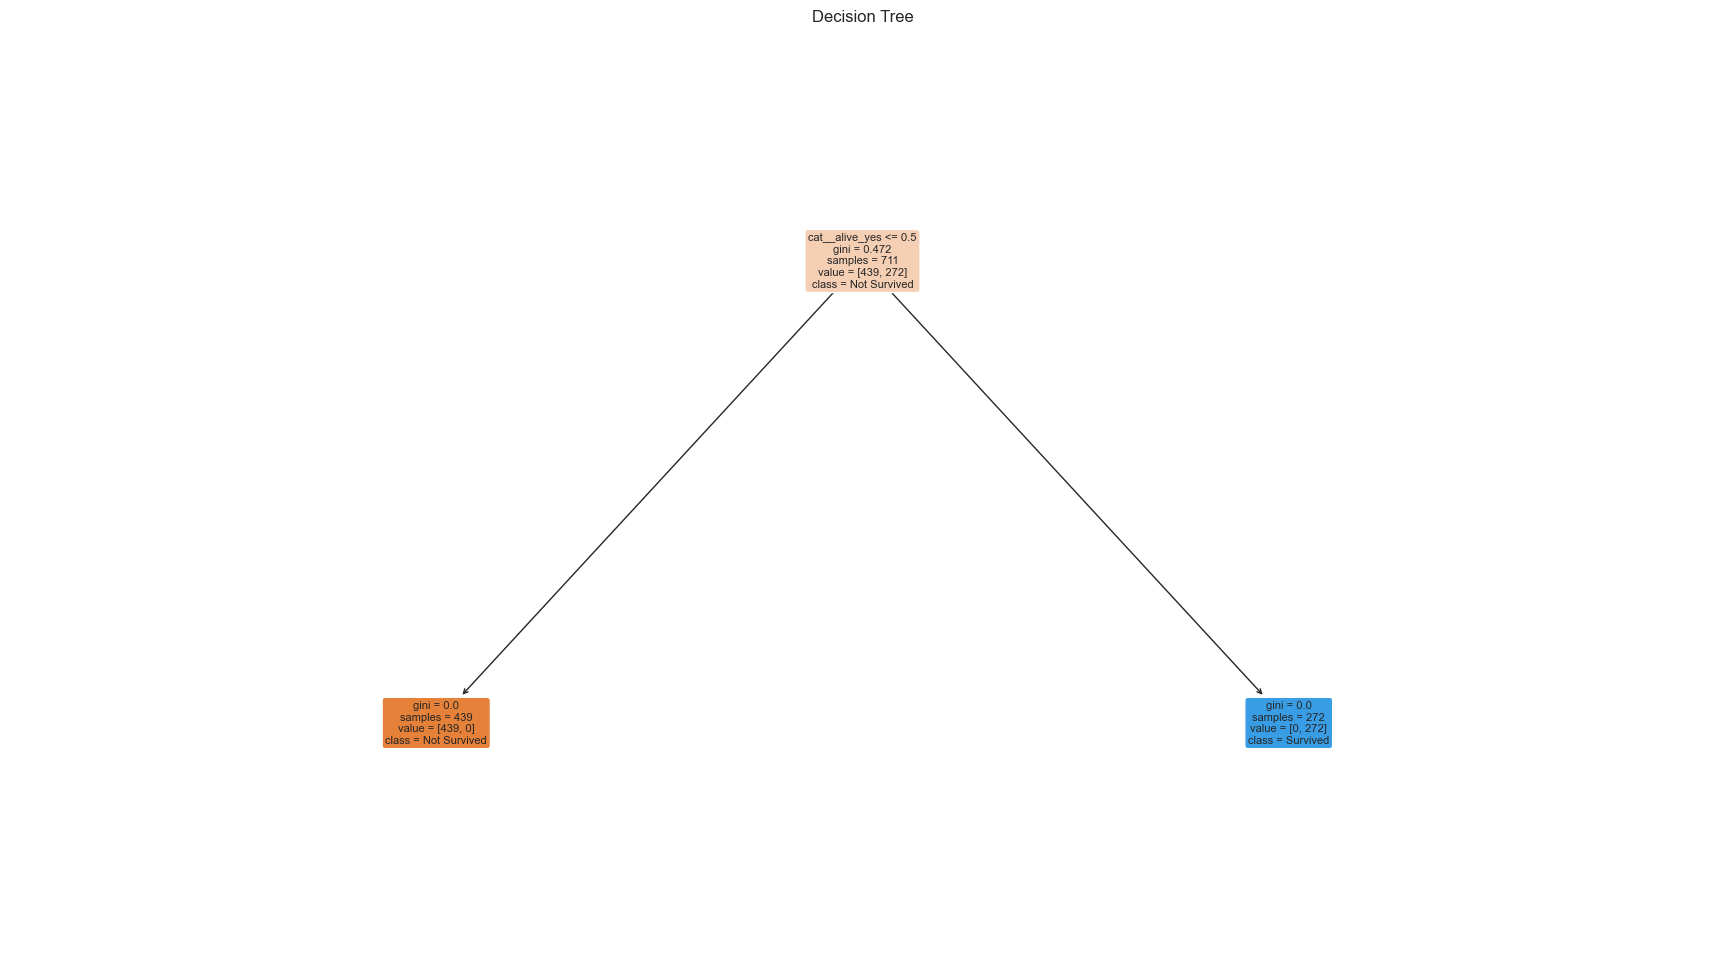

In [28]:
# Decision tree visualization with feature names and class names
tree_pipe = fitted_pipelines["Decision Tree"]
tree_model = tree_pipe.named_steps["model"]
pre = tree_pipe.named_steps["preprocessor"]

feature_names = pre.get_feature_names_out()

plt.figure(figsize=(22, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)
plt.title("Decision Tree")
plt.show()


# Imbalance handling comparison

We compare:
1. Baseline — no imbalance handling.
2. `class_weight='balanced'`.
3. SMOTE — applied **only inside the training pipeline**, never to the test set.


In [29]:
imbalance_models = {}

baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

smote_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

for name, pipe in [
    ("Baseline", baseline),
    ("Class Weight Balanced", balanced),
    ("SMOTE", smote_pipe)
]:
    pipe.fit(X_train_m, y_train)
    pred = pipe.predict(X_test_m)
    imbalance_models[name] = {
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }

imbalance_df = pd.DataFrame(imbalance_models).T
display(imbalance_df.round(4))

best_strategy = imbalance_df["F1"].idxmax()
print(
    f"Based on F1 on this fixed test set, {best_strategy} produced the highest F1. "
    "Precision and recall should also be considered because changing class weighting/SMOTE "
    "can trade precision against recall."
)


AttributeError: 'NoneType' object has no attribute 'split'

# Random Forest hyperparameter tuning

The search tunes `n_estimators`, `max_depth`, and `max_features`. The final Random Forest estimator is explicitly constructed with `oob_score=True`, so an OOB score is available after fitting.


In [30]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_m, y_train)

print("Best parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_.named_steps["model"]
print("Best CV F1:", grid.best_score_)
print("OOB score:", best_rf.oob_score_)


Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Best CV F1: 1.0
OOB score: 1.0


# Regression side-task — predict `fare`

The regression target is `fare`. To avoid target leakage, `fare` is removed from the regression feature set. A separate preprocessing pipeline handles missing values, categorical encoding, and scaling.


In [32]:
reg_df = df.copy()

X_reg = reg_df.drop(columns=["fare"])
y_reg = reg_df["fare"]

# Remove the binary target from the classification task if it remains in the regression data.
if "survived" in X_reg.columns:
    X_reg = X_reg.drop(columns=["survived"])

for c in ["adult_male", "alone"]:
    if c in X_reg.columns:
        X_reg = X_reg.drop(columns=[c])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

reg_num = Xr_train.select_dtypes(include=["number"]).columns.tolist()
reg_cat = Xr_train.select_dtypes(exclude=["number"]).columns.tolist()

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), reg_num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), reg_cat)
    ]
)

reg_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

reg_pipeline.fit(Xr_train, yr_train)
yr_pred = reg_pipeline.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

n = len(yr_test)
p = reg_pipeline.named_steps["preprocessor"].transform(Xr_test).shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

reg_metrics = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
}, index=["Linear Regression"])

display(reg_metrics.round(4))


,MAE,RMSE,R2,Adjusted R2
Linear Regression,17.7238,41.4054,0.3574,0.2755


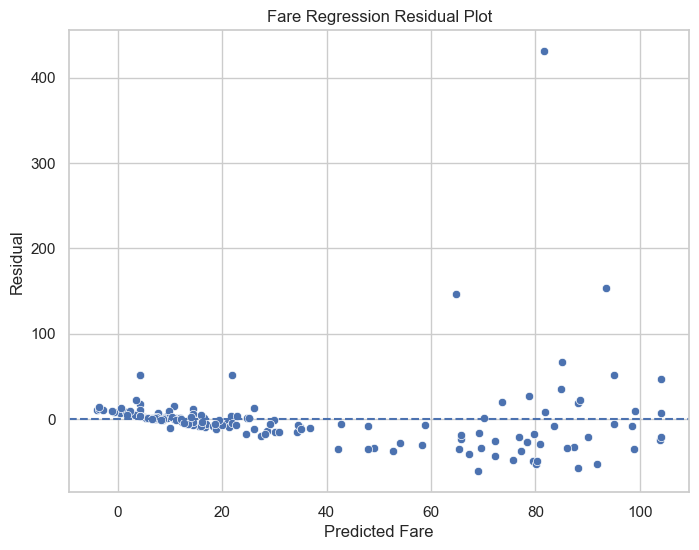

Correlation between predicted values and residuals: -0.0339
Heteroscedasticity assessment: inspect the residual plot for a funnel/non-random spread. A clearly widening or narrowing residual spread indicates heteroscedasticity; a roughly constant random spread provides less evidence of it.


In [33]:
residuals = yr_test - yr_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=yr_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Fare Regression Residual Plot")
plt.show()

# Simple visual diagnostic statement
corr_resid_pred = np.corrcoef(yr_pred, residuals)[0, 1]
print(f"Correlation between predicted values and residuals: {corr_resid_pred:.4f}")
print(
    "Heteroscedasticity assessment: inspect the residual plot for a funnel/non-random spread. "
    "A clearly widening or narrowing residual spread indicates heteroscedasticity; a roughly "
    "constant random spread provides less evidence of it."
)


In [34]:
# Final classification comparison table
classification_table = results_df[["Accuracy", "Precision", "Recall", "F1", "AUC"]].copy()
classification_table.index.name = "Classifier"

print("Classification metrics:")
display(classification_table.round(4))

print("Regression metrics — separate metric group:")
display(reg_metrics.round(4))


Classification metrics:


,Accuracy,Precision,Recall,F1,AUC
Classifier,,,,,
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0


Regression metrics — separate metric group:


,MAE,RMSE,R2,Adjusted R2
Linear Regression,17.7238,41.4054,0.3574,0.2755
